In [ ]:
import pandas as pd

df = pd.read_parquet('/content/yellow_tripdata_2025-01.parquet')

In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [ ]:
df['RatecodeID'].value_counts(normalize=True, dropna=False)*100

,proportion
RatecodeID,
1.0,79.317777
NaN,15.542845
2.0,2.716946
99.0,1.207490
5.0,0.762569
3.0,0.248099
4.0,0.204073
6.0,0.000201


# 🚕 Taxi проєкт: Аналіз витрат на поїздки Yellow Taxi (NYC)

У цьому проєкті ви працюєте з реальними даними Yellow Taxi Trip Records (January 2025) у форматі parquet.

[Дані на Kaggle](https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data). Вони велетенські (по 2 Гб), тому скачуйте лише якщо хочете працювати з ними локально

Ті самі [дані на сайті TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page). Якщо брати Yellow Taxi за один місяць (для прикладу January), файл parquet буде десь 50-100МБ до розпаковки. [Ось тут є документація](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf) для декодування.

🔹 Завдання: Розподіл вартості поїздок по категоріях

📌 Побудуйте boxplot/violin plot вартості поїздок по категоріях.
У якій категорії поїздки мають найбільшу варіативність ціни?

Підказка:

* Використайте поле payment_type або RatecodeID як категорію

* Використайте fare_amount або total_amount як суму поїздки

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import random
palette = sns.color_palette('bright', 10)
random.shuffle(palette)
df['RatecodeID'] = df['RatecodeID'].fillna(99).astype(int)
mapping_dict = {  'VendorID': {
                      1: 'Creative Mobile Technologies, LLC',
                      2: 'Curb Mobility, LLC',
                      6: 'Myle Technologies Inc',
                      7: 'Helix'
                  },
                  'RatecodeID': {
                      1:'Standard rate',
                      2: 'JFK',
                      3: 'Newark',
                      4: 'Nassau or Westchester',
                      5: 'Negotiated fare',
                      6: 'Group ride',
                      99: 'Null/unknown'
                  },
                  'payment_type':  {
                      0: 'Flex Fare trip',
                      1: 'Credit card',
                      2: 'Cash',
                      3: 'No charge',
                      4: 'Dispute',
                      5: 'Unknown',
                      6: 'Voided trip'
                  }
                }
mapping_columns = {
    f"{col}_name": df[col].map(mapping_col)
    for col, mapping_col in mapping_dict.items()
}
df = df.assign(**mapping_columns)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 24 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             int64         
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [ ]:
df['RatecodeID'].value_counts(normalize=True)*100

,proportion
RatecodeID,
1,79.317777
99,16.750335
2,2.716946
5,0.762569
3,0.248099
4,0.204073
6,0.000201


In [ ]:
df.groupby(['RatecodeID_name'])['total_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
RatecodeID_name,,,,,,,,
Group ride,7.0,4.892857,1.162407,4.00,4.000,4.000,5.75,6.75
JFK,94420.0,86.922793,34.543707,-170.19,85.940,95.190,99.78,293.62
Nassau or Westchester,7092.0,116.046056,109.397805,-865.39,60.550,112.195,165.07,2506.71
Negotiated fare,26501.0,72.925371,68.845724,-901.00,31.600,84.000,103.20,953.50
Newark,8622.0,95.067897,60.756455,-205.39,73.155,113.330,132.58,446.69
Null/unknown,582112.0,21.194590,13.700181,-33.82,13.410,19.510,27.00,531.90
Standard rate,2756472.0,23.539092,520.261560,-342.80,15.350,19.650,26.45,863380.37


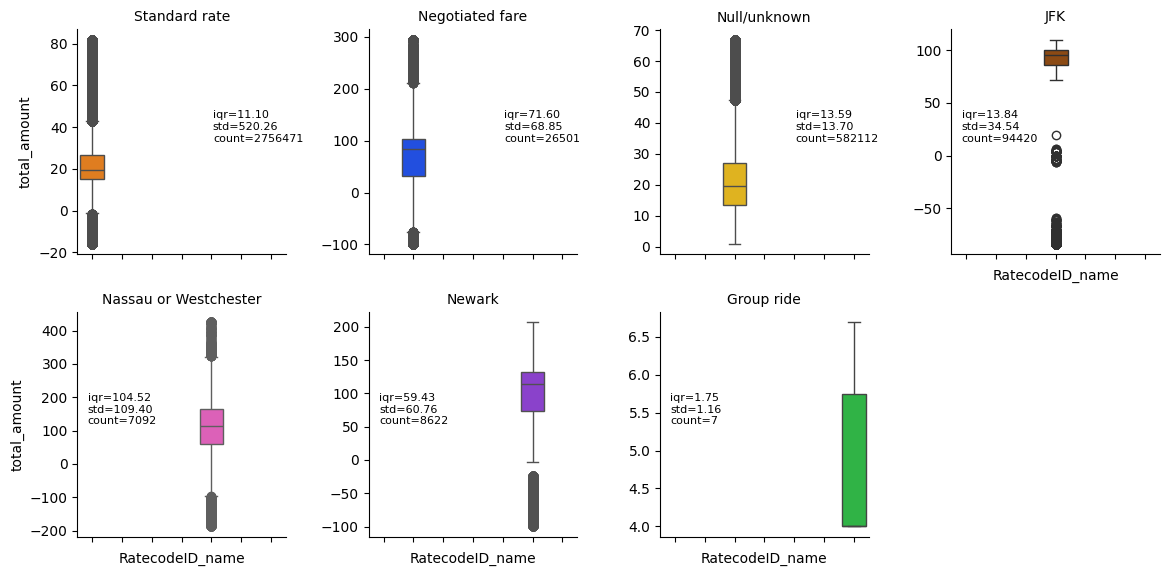

In [ ]:
df_vinz = df.query("payment_type_name != 'Unknown'").copy()
stat_dict = {}
for cat in df_vinz['RatecodeID_name'].unique():
    cond = df_vinz['RatecodeID_name'] == cat
    i_cat = df_vinz.loc[cond, 'total_amount']

    q_min = i_cat.quantile(0.01)
    q1 = i_cat.quantile(0.25)
    q3 = i_cat.quantile(0.75)
    q_max = i_cat.quantile(0.99)

    stat_dict[cat] = {
        'iqr': q3 - q1,
        'std': i_cat.std(),
        'count': i_cat.count()
    }

    df_vinz.loc[cond, 'total_amount'] = i_cat.clip(lower=q_min, upper=q_max)
grid = sns.FacetGrid(
    df_vinz,
    col="RatecodeID_name",
    hue='RatecodeID_name',
    palette=palette,
    col_wrap=4,
    sharey=False,
    margin_titles=True
)

grid.set_titles(col_template="{col_name}")
grid.map_dataframe(sns.boxplot, x='RatecodeID_name', y='total_amount')

for cat, ax in grid.axes_dict.items():
  iqr = stat_dict[cat]['iqr']
  std = stat_dict[cat]['std']
  count = stat_dict[cat]['count']
  i = list(grid.axes_dict.keys()).index(cat)
  x = 0.65 if i < 3 else 0.05

  ax.text(x, 0.5, f'iqr={iqr:.2f}\nstd={std:.2f}\ncount={count}',
            transform=ax.transAxes,
            fontsize=8
          )

grid.set_xticklabels([])
plt.show()



Із статистики та графіків по групах видно, що найбільше відхилення вартості поїздки (std>520) спостерігається у категорії із стандартною таксою, що може навести на хибне уявлення про найвищу варіативність. Проте розкид стандартних значень iqr для цієї категорії найнижчий серед усіх інших категорій (11,1). Тобто такий високий std скоріш за все повязаний з аномальними викидами. А от найбільша варіативність спостерігається для категорії Nassau or Westchester - стандартний розкид більше 100$.

⭐ Бонус: Статистична різниця між категоріями

Оберіть дві категорії (наприклад, payment_type = 1 vs payment_type = 2).

📌 Перевірте, чи існує статистично значуща різниця між розподілами вартості поїздок у цих категоріях.

In [ ]:
df_vinz.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3475225 entries, 0 to 3475225
Data columns (total 24 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             int64         
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            floa

🔹 Завдання : Часовий ряд — загальна сума поїздок за днями

📌 Побудуйте часовий ряд:
загальна сума доходу від поїздок по днях.

Кроки:

* Перетворіть tpep_pickup_datetime у дату
* Агрегуйте total_amount по днях
* Побудуйте графік
* 📌 Зробіть прогноз на 3–7 днів вперед, використовуючи:

`ARIMA(order=(1,1,1))`

Оптимізацію параметрів робити не потрібно (хіба що хочеться).

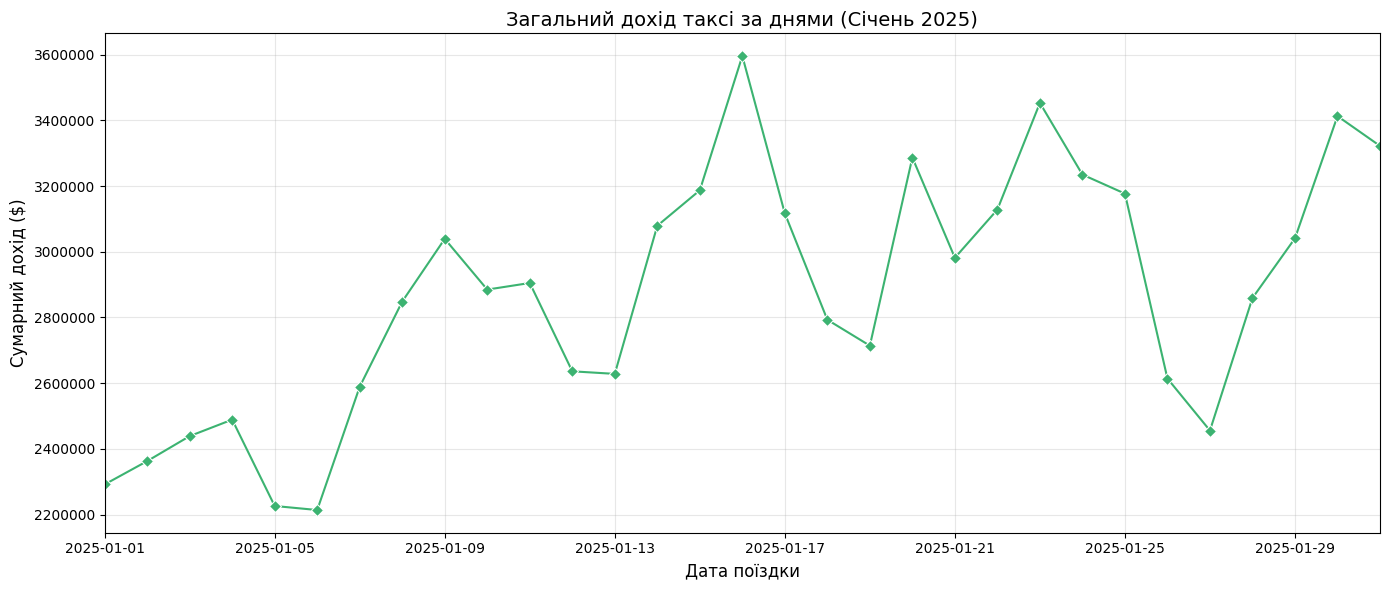

In [ ]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_day'] = df['tpep_pickup_datetime'].dt.date
df_jan = df[df['tpep_pickup_datetime'].dt.month == 1].copy()
daily_revenue = df_jan.groupby('pickup_day')['total_amount'].sum().reset_index()
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_revenue, x='pickup_day', y='total_amount', marker='D', color='mediumseagreen')

plt.title('Загальний дохід таксі за днями (Січень 2025)', fontsize=14)
plt.xlim(daily_revenue['pickup_day'].min(), daily_revenue['pickup_day'].max())
plt.xlabel('Дата поїздки', fontsize=12)
plt.ylabel('Сумарний дохід ($)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

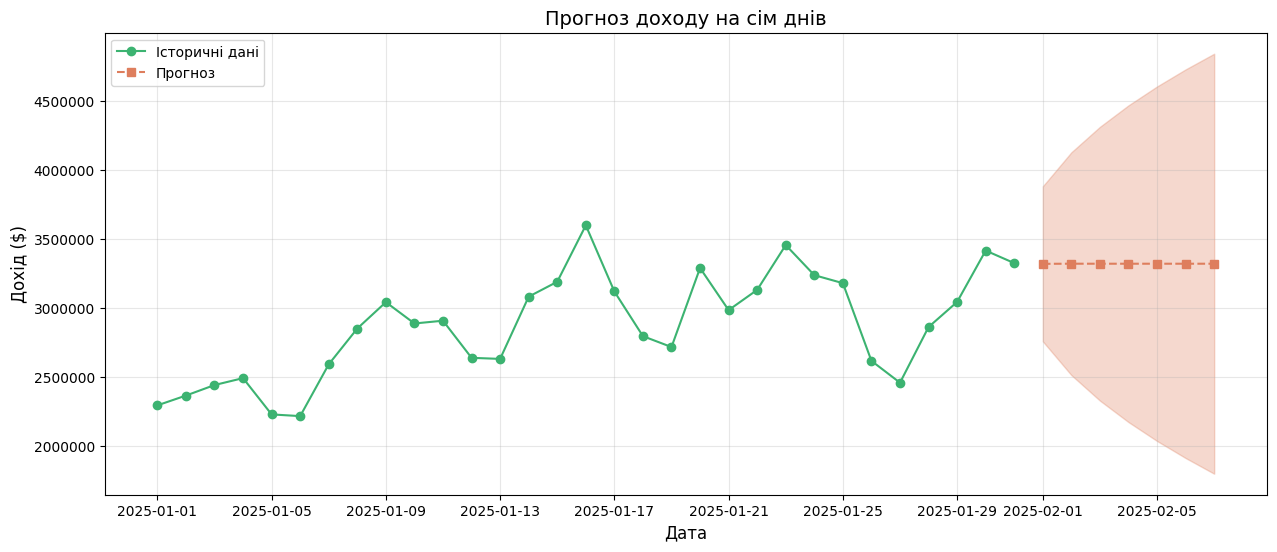

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

daily_revenue = df_jan.groupby('pickup_day')['total_amount'].sum()
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_day'] = df['tpep_pickup_datetime'].dt.date
df_jan = df[df['tpep_pickup_datetime'].dt.month == 1].copy()
daily_revenue.index = pd.to_datetime(daily_revenue.index)
daily_revenue = pd.Series(daily_revenue.values.astype(float), index=daily_revenue.index)


model = ARIMA(daily_revenue, order=(1, 1, 1))
model_fit = model.fit()

N = 7
forecast = model_fit.get_forecast(steps=N)
pred = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(15, 6))
plt.plot(daily_revenue.index, daily_revenue, label='Історичні дані', marker='o', color='mediumseagreen')
plt.plot(pred.index, pred, label='Прогноз', marker='s', color='#de7e5d', linestyle='--')

plt.fill_between(pred.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='#de7e5d', alpha=0.3)

plt.title('Прогноз доходу на сім днів', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Дохід ($)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



🔹 Завдання: Чи рівномірно розподілені вартості поїздок?

📌 Побудуйте:
* гістограму
* або violin plot
для total_amount.

📌 Визначте:
* чи розподіл симетричний
* чи є правостороння асиметрія
* чи є розподіл нормальним (код)

Підказка:
* Якщо середнє > медіани → розподіл правоскосий.

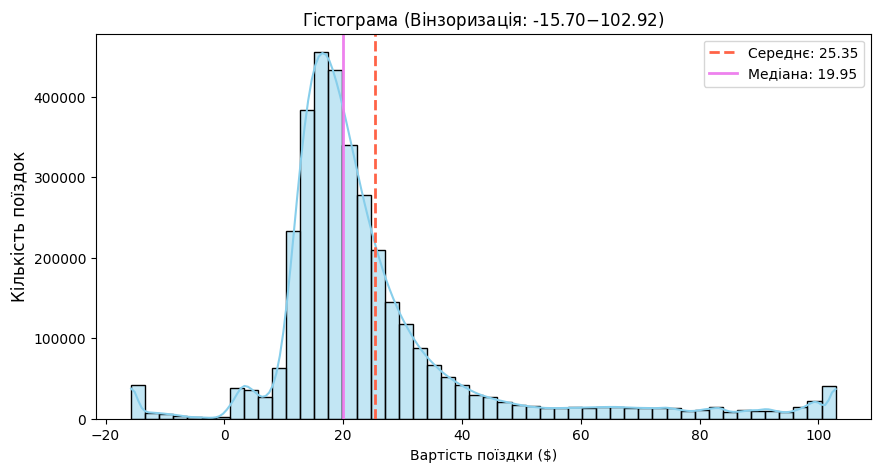

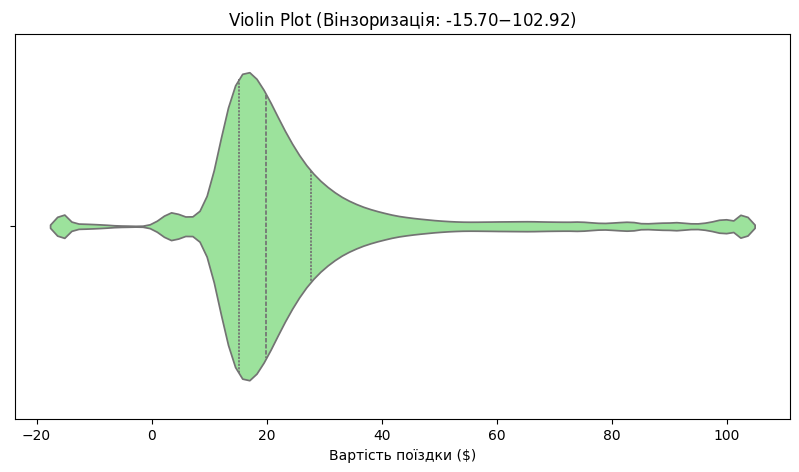

In [ ]:
q_min = df['total_amount'].quantile(0.01)
q_max = df['total_amount'].quantile(0.99)
df_vinz = df.copy()
df_vinz['total_amount'] = df['total_amount'].clip(lower=q_min, upper=q_max)
mean = df_vinz['total_amount'].mean()
median = df_vinz['total_amount'].median()
plt.figure(figsize=(10, 5))
sns.histplot(df_vinz['total_amount'], kde=True, bins=50, color='skyblue')
plt.axvline(mean, color='tomato', linestyle='--', linewidth=2, label=f'Середнє: {mean:.2f}')
plt.axvline(median, color='violet', linestyle='-', linewidth=2, label=f'Медіана: {median:.2f}')
plt.title(f'Гістограма (Вінзоризація: {q_min:.2f}$ - {q_max:.2f}$)')
plt.xlabel('Вартість поїздки ($)')
plt.ylabel('Кількість поїздок', fontsize=12)
plt.legend()
plt.show()
plt.figure(figsize=(10, 5))
sns.violinplot(x=df_vinz['total_amount'], inner='quartile', color='lightgreen')
plt.title(f'Violin Plot (Вінзоризація: {q_min:.2f}$ - {q_max:.2f}$)')
plt.xlabel('Вартість поїздки ($)')
plt.show()


Як видно з графіків, розподіл вартості поїздок асиметричний правосторонній.

In [ ]:
from scipy.stats import shapiro, kstest

print("Тест на нормальність по категоріях:")

for cat in df_vinz['RatecodeID_name'].unique():
    data = df_vinz[df_vinz['RatecodeID_name'] == cat]['total_amount']

    test_data = data.sample(min(len(data), 5000))

    stat, p = shapiro(test_data)

    result = '→ нормальний' if p > 0.05 else '→ не нормальний'
    print(f"Категорія {cat:20}: p = {p:.4f} {result}")


Тест на нормальність по категоріях:
Категорія Standard rate       : p = 0.0000 → не нормальний
Категорія Negotiated fare     : p = 0.0000 → не нормальний
Категорія Null/unknown        : p = 0.0000 → не нормальний
Категорія JFK                 : p = 0.0000 → не нормальний
Категорія Nassau or Westchester: p = 0.0000 → не нормальний
Категорія Newark              : p = 0.0000 → не нормальний
Категорія Group ride          : p = 0.0174 → не нормальний


🔹 Завдання: Кореляція між часом доби та сумою поїздки

📌 Дослідіть, чи залежить вартість поїздки від часу доби.

Кроки:

* Витягніть годину з tpep_pickup_datetime
* Побудуйте scatter plot: hour vs total_amount
* Обчисліть коефіцієнт кореляції (Pearson або Spearman)

`df['hour'] = df['tpep_pickup_datetime'].dt.hour`

`df[['hour','total_amount']].corr()`

📌 Напишіть короткий висновок.

In [ ]:
df_vinz['hour'] = df_vinz['tpep_pickup_datetime'].dt.hour
correlation = df_vinz[['hour', 'total_amount']].corr(method='spearman').iloc[0, 1]

print(f"Коефіцієнт кореляції Спірмена: {correlation:.4f}")

Коефіцієнт кореляції Спірмена: 0.0478


Тобто кореляції майже немає

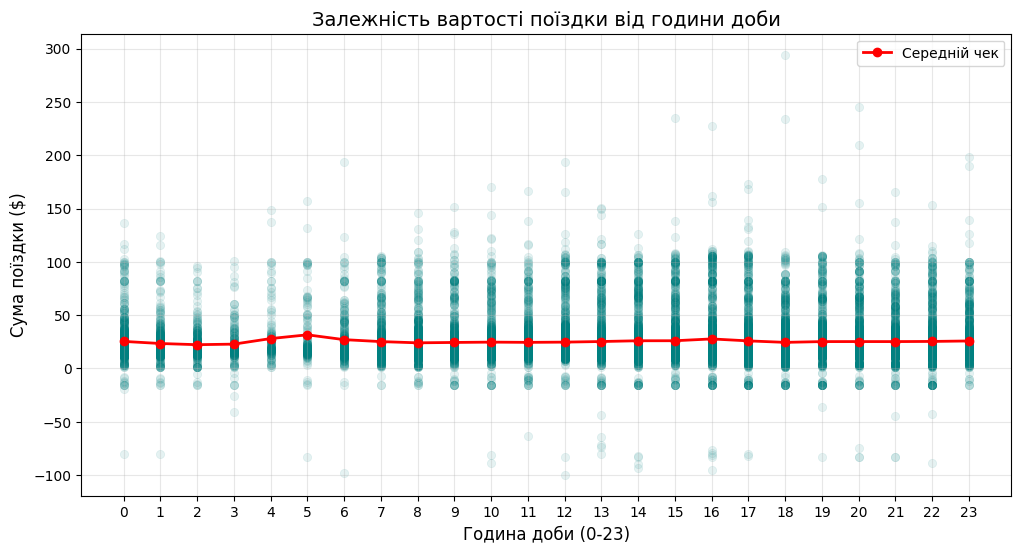

In [ ]:
plt.figure(figsize=(12, 6))

sns.scatterplot(data=df_vinz.sample(20000), x='hour', y='total_amount',
                alpha=0.1, color='teal', edgecolor=None)

hourly_avg = df_vinz.groupby('hour')['total_amount'].mean()
plt.plot(hourly_avg.index, hourly_avg.values, color='red', marker='o',
         linewidth=2, label='Середній чек')

plt.title('Залежність вартості поїздки від години доби', fontsize=14)
plt.xlabel('Година доби (0-23)', fontsize=12)
plt.ylabel('Сума поїздки ($)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Це видно і з графіка, що сума поїздки майже не залежить від години доби.